# Data Preprocessing - Credit Card Customers Churn

Các bước preprocessing:
1. Handle missing values bằng NumPy
2. Detect và xử lý outliers
3. Normalize/Standardize features
4. Encode categorical variables
5. Handle class imbalance (SMOTE)
6. Dimensionality reduction (PCA)
7. **Create 2 versions** (Basic vs Enhanced)
8. Save processed data

In [59]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

np.random.seed(42)

In [60]:
sys.path.append(os.path.abspath('..'))

from src.data_processing import (
    MissingValueHandler,
    OutlierDetector,
    Normalizer,
    FeatureEncoder,
    SMOTE,
    PCA,
    DataSplitter,
    save_processed_data,
    load_processed_data
)
from src.visualization import DataVisualizer

In [61]:
# Load data
data_path = '../data/raw/BankChurners.csv'

# Load headers
with open(data_path, 'r') as f:
    header_line = f.readline().strip()
    headers = np.array(header_line.replace('"', '').split(','))

# Load data
data = np.genfromtxt(
    data_path,
    delimiter=',',
    dtype=str,
    skip_header=1,
    encoding='utf-8'
)
# Remove quotes
data = np.char.replace(data, '"', '')

In [62]:
# Define columns
target_col = 1
numeric_cols = [2, 4, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
categorical_cols = [3, 5, 6, 7, 8]

# Extract data
y_raw = data[:, target_col]
X_numeric = data[:, numeric_cols].astype(np.float64)
X_categorical = data[:, categorical_cols]
numeric_names = headers[numeric_cols]
categorical_names = headers[categorical_cols]

print(f"Data loaded: {data.shape}")
print(f"Numeric features: {X_numeric.shape}")
print(f"Categorical features: {X_categorical.shape}")

Data loaded: (10127, 23)
Numeric features: (10127, 14)
Categorical features: (10127, 5)


# 1. Handle Missing Values (**Median**)

In [63]:
# Check for missing values
handler = MissingValueHandler()

missing_mask = np.isnan(X_numeric)
missing_count = np.sum(missing_mask, axis=0)

print("\nMissing values per feature:")
for name, count in zip(numeric_names, missing_count):
    if count > 0:
        print(f"{name}: {count} missing values")
    
if np.sum(missing_count) == 0:
    print("NO MISSING VALUES found in numeric features")
else:
    # Fill missing values with median
    X_numeric = handler.fill_median(X_numeric)
    print("Missing values filled with median.")

# Handle categorical missing values
X_categorical = handler.fill_mode(X_categorical)
print("Categorical missing values handled.")


Missing values per feature:
NO MISSING VALUES found in numeric features
Categorical missing values handled.


# 2. Outlier Detection and Handling (**IQR Method**)

<p align="center">
  <img src="../assets/iqr.jpg" width="600">
</p>

In [64]:
# Detect outliers using IQR method
detector = OutlierDetector()
outlier_mask = detector.iqr_method(X_numeric, k=1.5)

print("Outlier detection results:")
outliers_per_feature = np.sum(outlier_mask, axis=0)
for name, count in zip(numeric_names, outliers_per_feature):
    percentage = (count / X_numeric.shape[0]) * 100
    print(f"  - {name}: {count} outliers ({percentage:.2f}%)")

# Cap outliers instead of removing (to preserve data)
X_numeric_clean = detector.cap_outliers(X_numeric, outlier_mask)
print(f"\nData shape preserved: {X_numeric_clean.shape}")

Outlier detection results:
  - Customer_Age: 2 outliers (0.02%)
  - Dependent_count: 0 outliers (0.00%)
  - Months_on_book: 386 outliers (3.81%)
  - Total_Relationship_Count: 0 outliers (0.00%)
  - Months_Inactive_12_mon: 331 outliers (3.27%)
  - Contacts_Count_12_mon: 629 outliers (6.21%)
  - Credit_Limit: 984 outliers (9.72%)
  - Total_Revolving_Bal: 0 outliers (0.00%)
  - Avg_Open_To_Buy: 963 outliers (9.51%)
  - Total_Amt_Chng_Q4_Q1: 396 outliers (3.91%)
  - Total_Trans_Amt: 896 outliers (8.85%)
  - Total_Trans_Ct: 2 outliers (0.02%)
  - Total_Ct_Chng_Q4_Q1: 394 outliers (3.89%)
  - Avg_Utilization_Ratio: 0 outliers (0.00%)

Data shape preserved: (10127, 14)


# 3. Normalization (**Z-score Standardization**)

<p align="center">
  <img src="../assets/z_score.jpg" width="600">
</p>

Z-score Standardization applied
Features normalized: 14
Mean after standardization (first 3): [ 3.17839300e-16  5.73315574e-15 -2.92931364e-16]
Std after standardization (first 3): [1. 1. 1.]


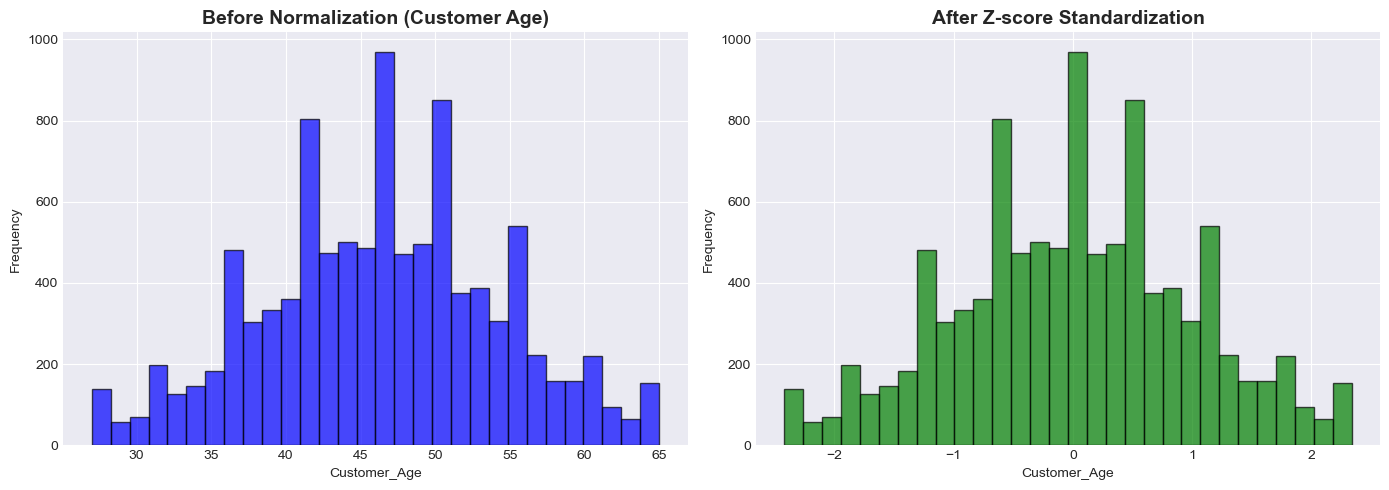

In [65]:
# Apply Z-score standardization to numeric features
normalizer = Normalizer()
X_normalized, norm_params = normalizer.z_score_standardization(X_numeric_clean)

print("Z-score Standardization applied")
print(f"Features normalized: {X_normalized.shape[1]}")
print(f"Mean after standardization (first 3): {np.mean(X_normalized, axis=0)[:3]}")
print(f"Std after standardization (first 3): {np.std(X_normalized, axis=0)[:3]}")

# Visualize before and after
visualizer = DataVisualizer()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before 
ax1.hist(X_numeric_clean[:, 0], bins=30, alpha=0.7, color='blue', edgecolor='black')
ax1.set_title('Before Normalization (Customer Age)', fontsize=14, fontweight='bold')
ax1.set_xlabel(numeric_names[0])
ax1.set_ylabel('Frequency')

# After 
ax2.hist(X_normalized[:, 0], bins=30, alpha=0.7, color='green', edgecolor='black')
ax2.set_title('After Z-score Standardization', fontsize=14, fontweight='bold')
ax2.set_xlabel(numeric_names[0])
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 4. Encode Categorical Features (**Label Encoding**)

<p align="center">
  <img src="../assets/label_encoding.png" width="600">
</p>

In [66]:
# Encode categorical features
encoder = FeatureEncoder()
X_categorical_encoded, cat_mappings = encoder.label_encode(X_categorical)

print("Categorical encoding completed:")
for idx, name in enumerate(categorical_names):
    n_unique = len(cat_mappings[idx])
    print(f"{name}: {n_unique} unique values encoded")

# Encode target variable
y_binary = (y_raw == 'Attrited Customer').astype(int)
print(f"\nTarget encoded: 0 = Existing Customer, 1 = Attrited Customer")

Categorical encoding completed:
Gender: 2 unique values encoded
Education_Level: 7 unique values encoded
Marital_Status: 4 unique values encoded
Income_Category: 6 unique values encoded
Card_Category: 4 unique values encoded

Target encoded: 0 = Existing Customer, 1 = Attrited Customer


# Combine All Features


In [67]:
# Combine numeric and categorical features
X_final = np.hstack([X_normalized, X_categorical_encoded])

print(f"Final feature matrix shape: {X_final.shape}")
print(f"  - Numeric features: {X_normalized.shape[1]}")
print(f"  - Categorical features: {X_categorical_encoded.shape[1]}")
print(f"  - Total features: {X_final.shape[1]}")


Final feature matrix shape: (10127, 19)
  - Numeric features: 14
  - Categorical features: 5
  - Total features: 19


# 5. Handle Class Imbalance with SMOTE

<p align="center">
  <img src="../assets/smote.png" width="600">
</p>

Class distribution BEFORE SMOTE:
  Class 0: 8500
  Class 1: 1627
SMOTE applied: 10127 -> 17000 samples
Class distribution: [8500 8500]

Class distribution AFTER SMOTE:
  Class 0: 8500
  Class 1: 8500


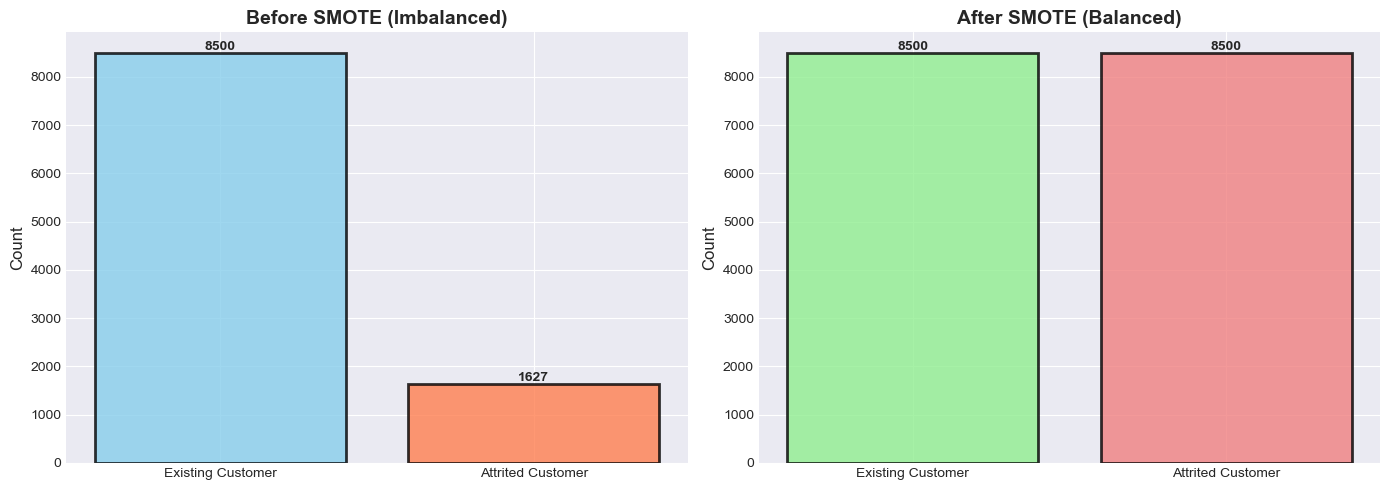

In [68]:
from src.data_processing import SMOTE

# Check class imbalance
print("Class distribution BEFORE SMOTE:")
print(f"  Class 0: {np.sum(y_binary == 0)}")
print(f"  Class 1: {np.sum(y_binary == 1)}")

# Apply SMOTE to balance classes
smote = SMOTE(k_neighbors=5, random_state=42)
X_final_balanced, y_balanced = smote.fit_resample(X_final, y_binary)

print("\nClass distribution AFTER SMOTE:")
print(f"  Class 0: {np.sum(y_balanced == 0)}")
print(f"  Class 1: {np.sum(y_balanced == 1)}")

# Visualize class distribution
visualizer = DataVisualizer()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before 
unique_before, counts_before = np.unique(y_binary, return_counts=True)
ax1.bar(['Existing Customer', 'Attrited Customer'], counts_before, 
        color=['skyblue', 'coral'], alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_title('Before SMOTE (Imbalanced)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12)
for i, count in enumerate(counts_before):
    ax1.text(i, count, str(count), ha='center', va='bottom', fontweight='bold')

# After 
unique_after, counts_after = np.unique(y_balanced, return_counts=True)
ax2.bar(['Existing Customer', 'Attrited Customer'], counts_after,
        color=['lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_title('After SMOTE (Balanced)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12)
for i, count in enumerate(counts_after):
    ax2.text(i, count, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Apply PCA for Dimensionality Reduction

<p align="center">
  <img src="../assets/pca.png" width="600">
</p>

PCA fitted with 4 components
Explained variance ratio: [0.48772361 0.33944879 0.07954981 0.06869017]
Total explained variance: 0.9754

PCA Components created: (10127, 4)
Feature names: ['PC-0', 'PC-1', 'PC-2', 'PC-3']


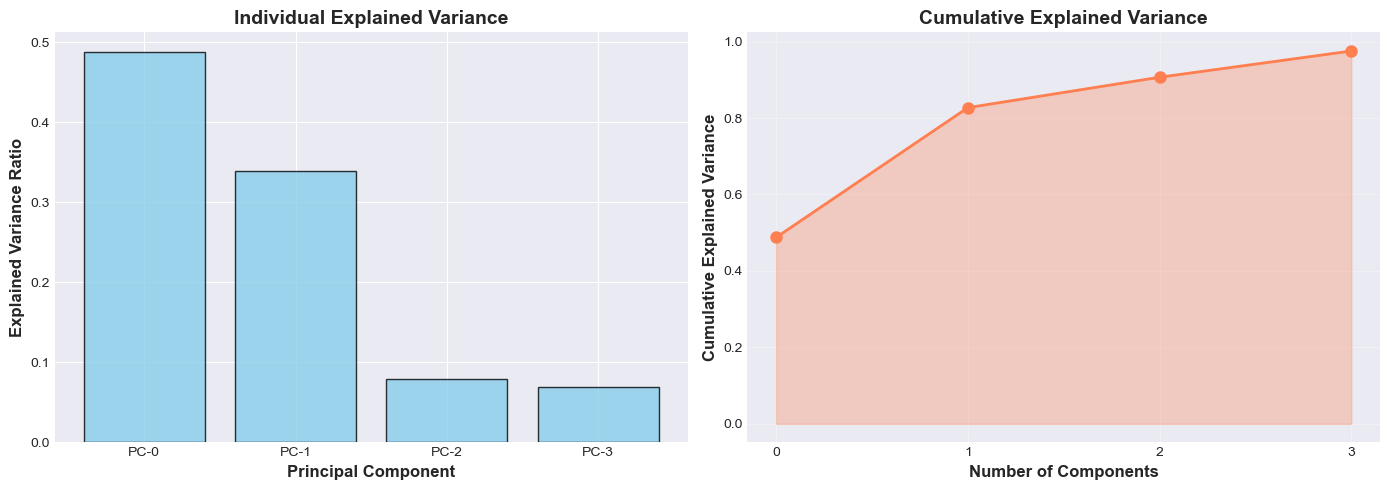


PCA captures 97.54%


In [69]:
from src.data_processing import PCA

N_COMPONENTS = 4

# Apply PCA to categorical features
pca = PCA(n_components=N_COMPONENTS)
X_categorical_pca = pca.fit_transform(X_categorical_encoded.astype(np.float64))

print(f"\nPCA Components created: {X_categorical_pca.shape}")
print(f"Feature names: {['PC-{}'.format(i) for i in range(N_COMPONENTS)]}")

# Visualize explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
ax1.bar(range(N_COMPONENTS), pca.explained_variance_ratio_, 
        color='skyblue', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax1.set_title('Individual Explained Variance', fontsize=14, fontweight='bold')
ax1.set_xticks(range(N_COMPONENTS))
ax1.set_xticklabels([f'PC-{i}' for i in range(N_COMPONENTS)])

# Cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
ax2.plot(range(N_COMPONENTS), cumsum_var, 'o-', linewidth=2, markersize=8, color='coral')
ax2.fill_between(range(N_COMPONENTS), cumsum_var, alpha=0.3, color='coral')
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax2.set_xticks(range(N_COMPONENTS))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPCA captures {np.sum(pca.explained_variance_ratio_):.2%}")


# Combine Features with PCA Components

In [70]:
# Combine normalized numeric features with PCA components
X_final_with_pca = np.hstack([X_normalized, X_categorical_pca])

print(f"Final feature matrix with PCA: {X_final_with_pca.shape}")
print(f"  - Numeric features: {X_normalized.shape[1]}")
print(f"  - PCA components: {X_categorical_pca.shape[1]}")
print(f"  - Total: {X_final_with_pca.shape[1]}")

# Now apply SMOTE on this enhanced feature set
X_enhanced_balanced, y_balanced = smote.fit_resample(X_final_with_pca, y_binary)

print(f"\n Enhanced features with SMOTE: {X_enhanced_balanced.shape}")


Final feature matrix with PCA: (10127, 18)
  - Numeric features: 14
  - PCA components: 4
  - Total: 18


d:\Downloads\Documents\Github Repo\HW2_NUMPY_FOR_DATA_SCIENCE\src\data_processing.py:256: RuntimeWarning: invalid value encountered in sqrt
  distances = np.sqrt(X_sq + X_sq.T - 2 * np.dot(X_minority, X_minority.T))


SMOTE applied: 10127 -> 17000 samples
Class distribution: [8500 8500]

 Enhanced features with SMOTE: (17000, 18)


# 7. Create Two Versions for Training

**VERSION 1 - Basic:**
- Features: Original 14 numeric + 5 categorical
- No SMOTE (imbalanced)
- No PCA

**VERSION 2 - Enhanced:**
- Features: 14 numeric + 4 PCA components
- With SMOTE (balanced classes)
- With PCA (dimensionality reduction)

In [73]:
# VERSION 1: Basic (No SMOTE, No PCA)
print("VERSION 1")
print(f"  Features shape: {X_final.shape}")
print(f"    - Numeric (normalized): {X_normalized.shape[1]}")
print(f"    - Categorical (encoded): {X_categorical_encoded.shape[1]}")
print(f"    - Total: {X_final.shape[1]}")
print(f"  Target distribution:")
print(f"    - Class 0 (Existing): {np.sum(y_binary == 0)}")
print(f"    - Class 1 (Attrited): {np.sum(y_binary == 1)}")

splitter = DataSplitter()
X_train_basic, X_test_basic, y_train_basic, y_test_basic = splitter.train_test_split(
    X_final, y_binary, test_size=0.2, random_state=42
)

print(f"Train/Test Split:")
print(f"    - Train: {X_train_basic.shape}, labels: {np.bincount(y_train_basic)}")
print(f"    - Test:  {X_test_basic.shape}, labels: {np.bincount(y_test_basic)}")

# VERSION 2: Enhanced (SMOTE + PCA)
print("\nVERSION 2")
print(f"  Features shape: {X_enhanced_balanced.shape}")
print(f"    - Numeric (normalized): {X_normalized.shape[1]}")
print(f"    - PCA components: {X_categorical_pca.shape[1]}")
print(f"    - Total: {X_final_with_pca.shape[1]}")
print(f"  Target distribution (after SMOTE):")
print(f"    - Class 0 (Existing): {np.sum(y_balanced == 0)}")
print(f"    - Class 1 (Attrited): {np.sum(y_balanced == 1)}")

X_train_enhanced, X_test_enhanced, y_train_enhanced, y_test_enhanced = splitter.train_test_split(
    X_enhanced_balanced, y_balanced, test_size=0.2, random_state=42
)

print(f"  Train/Test Split:")
print(f"    - Train: {X_train_enhanced.shape}, labels: {np.bincount(y_train_enhanced)}")
print(f"    - Test:  {X_test_enhanced.shape}, labels: {np.bincount(y_test_enhanced)}")

VERSION 1
  Features shape: (10127, 19)
    - Numeric (normalized): 14
    - Categorical (encoded): 5
    - Total: 19
  Target distribution:
    - Class 0 (Existing): 8500
    - Class 1 (Attrited): 1627
Train/Test Split:
    - Train: (8102, 19), labels: [6802 1300]
    - Test:  (2025, 19), labels: [1698  327]

VERSION 2
  Features shape: (17000, 18)
    - Numeric (normalized): 14
    - PCA components: 4
    - Total: 18
  Target distribution (after SMOTE):
    - Class 0 (Existing): 8500
    - Class 1 (Attrited): 8500
  Train/Test Split:
    - Train: (13600, 18), labels: [6823 6777]
    - Test:  (3400, 18), labels: [1677 1723]


# 8. Save Both Versions

Lưu cả 2 phiên bản để sử dụng cho training:

In [72]:
# Save VERSION 1: Basic
save_processed_data(X_train_basic, '../data/processed/X_train_basic.npy')
save_processed_data(X_test_basic, '../data/processed/X_test_basic.npy')
save_processed_data(y_train_basic, '../data/processed/y_train_basic.npy')
save_processed_data(y_test_basic, '../data/processed/y_test_basic.npy')
# Save VERSION 2: Enhanced
save_processed_data(X_train_enhanced, '../data/processed/X_train_enhanced.npy')
save_processed_data(X_test_enhanced, '../data/processed/X_test_enhanced.npy')
save_processed_data(y_train_enhanced, '../data/processed/y_train_enhanced.npy')
save_processed_data(y_test_enhanced, '../data/processed/y_test_enhanced.npy')

Saved processed data to ../data/processed/X_train_basic.npy
Saved processed data to ../data/processed/X_test_basic.npy
Saved processed data to ../data/processed/y_train_basic.npy
Saved processed data to ../data/processed/y_test_basic.npy
Saved processed data to ../data/processed/X_train_enhanced.npy
Saved processed data to ../data/processed/X_test_enhanced.npy
Saved processed data to ../data/processed/y_train_enhanced.npy
Saved processed data to ../data/processed/y_test_enhanced.npy
